<a href="https://colab.research.google.com/github/cjimenez275/Curso_python/blob/master/17_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perceptrón
para un conjunto de datos de entrenamiento "Personas" con características de edad y ahorro (normalizados) se tienen otra característica "clase" que indica si se le aprueba o no una tarjeta de crédito (0, 1). El perceptrón predice, con base en estos datos, si a una nueva persona se le debe o no aprobar una tarjeta de crédito

In [76]:
import numpy as np
import matplotlib.pyplot as plt

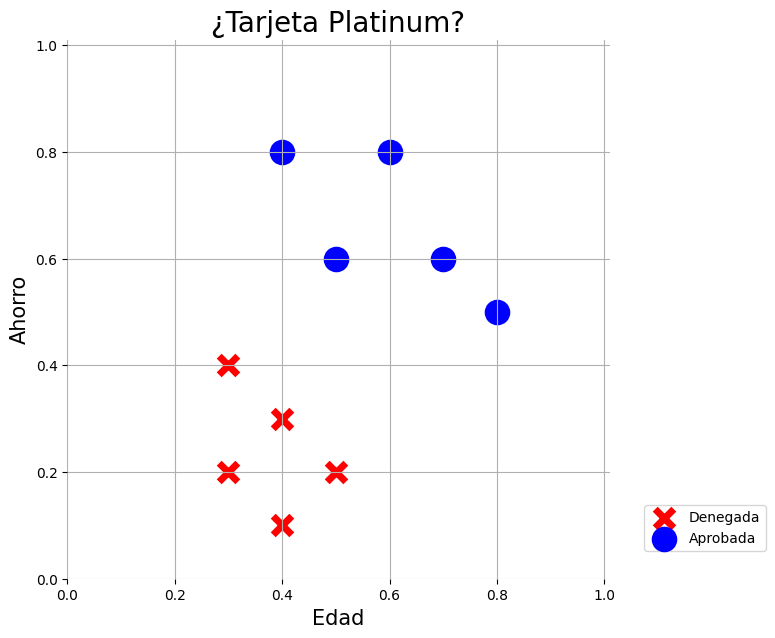

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de 10 personas -> [edad, ahorro]

personas = np.array([[0.3, 0.4], [0.4, 0.3],
                     [0.3, 0.2], [0.4, 0.1],
                     [0.5, 0.2], [0.4, 0.8],
                     [0.6, 0.8], [0.5, 0.6],
                     [0.7, 0.6], [0.8, 0.5]])

# 1 : aprobrada    0 : denegada

clases = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

# Gráfica de dispersión (edad, ahorro)
plt.figure(figsize=(7, 7))
plt.title("¿Tarjeta Platinum?", fontsize=20)
plt.scatter(personas[clases == 0].T[0],
            personas[clases == 0].T[1],
            marker="x", s=180, color="red",
            linewidths=5, label="Denegada")
plt.scatter(personas[clases == 1].T[0],
            personas[clases == 1].T[1],
            marker="o", s=180, color="blue",
            linewidths=5, label="Aprobada")
plt.xlabel("Edad", fontsize=15)
plt.ylabel("Ahorro", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False)
plt.xlim((0, 1.01))
plt.ylim((0, 1.01))
plt.grid()
plt.show()

Función de activación
Recibe como entrada pesos (vector 2d), inicialmente arbitrarios, las características x (vector2d), en este caso la edad y el ahorro, y una bias (umbral). si el producto de los pesos por las características x es mayor que un umbral b, entonces se activa (1)
pesos[0]x[0] + pesos[1]x[1] + b > 0 (se activa)

In [78]:
def activacion(pesos, x, b):
    z = pesos * x
    if z.sum() + b > 0:
        return 1
    else:
        return 0

pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)

pesos, b, activacion(pesos, [0.5, 0.4], b)

(array([-0.19109333, -0.88888403]), 0.5380065235043454, 1)

## Entrenamiento del perceptrón
Se inicia con valores de pesos y bias aleatorios, se llama la función de activación que da como resultado 0 o 1, se compara con la carcatrística conocida clase (0 o 1) se calcula el error, si hay error se actualiza las entradas pesos y x y se repite, con esto se encuentran los valores óptimos de los pesos, es decir se decide que que características son mas importantes y despues se testea con un valor nuevo

In [79]:
pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)
tasa_de_aprendizaje = 0.01
epocas = 100

for epoca in range(epocas):
    error_total = 0
    for i in range(len(personas)):
        prediccion = activacion(pesos, personas[i], b)
        error = clases[i] - prediccion
        error_total += error**2
        pesos[0] += tasa_de_aprendizaje * personas[i][0] * error
        pesos[1] += tasa_de_aprendizaje * personas[i][1] * error
        b += tasa_de_aprendizaje * error
    print(error_total, end=" ")

activacion(pesos, [0.8, 0.9], b)

5 5 5 5 5 3 3 2 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

1

## Zona de aprobación
En este caso se encuentra la división de los valores, la zona de activación, en este caso es lineal.
Con los datos de los pesos y el bias encontrados en la celda anterior, se crea una red recorriendo edad y ahorros en pasos de 0.05 y se evalúa si se activa (azul) o no (rojo), se grafica además los valores de entrenamiento

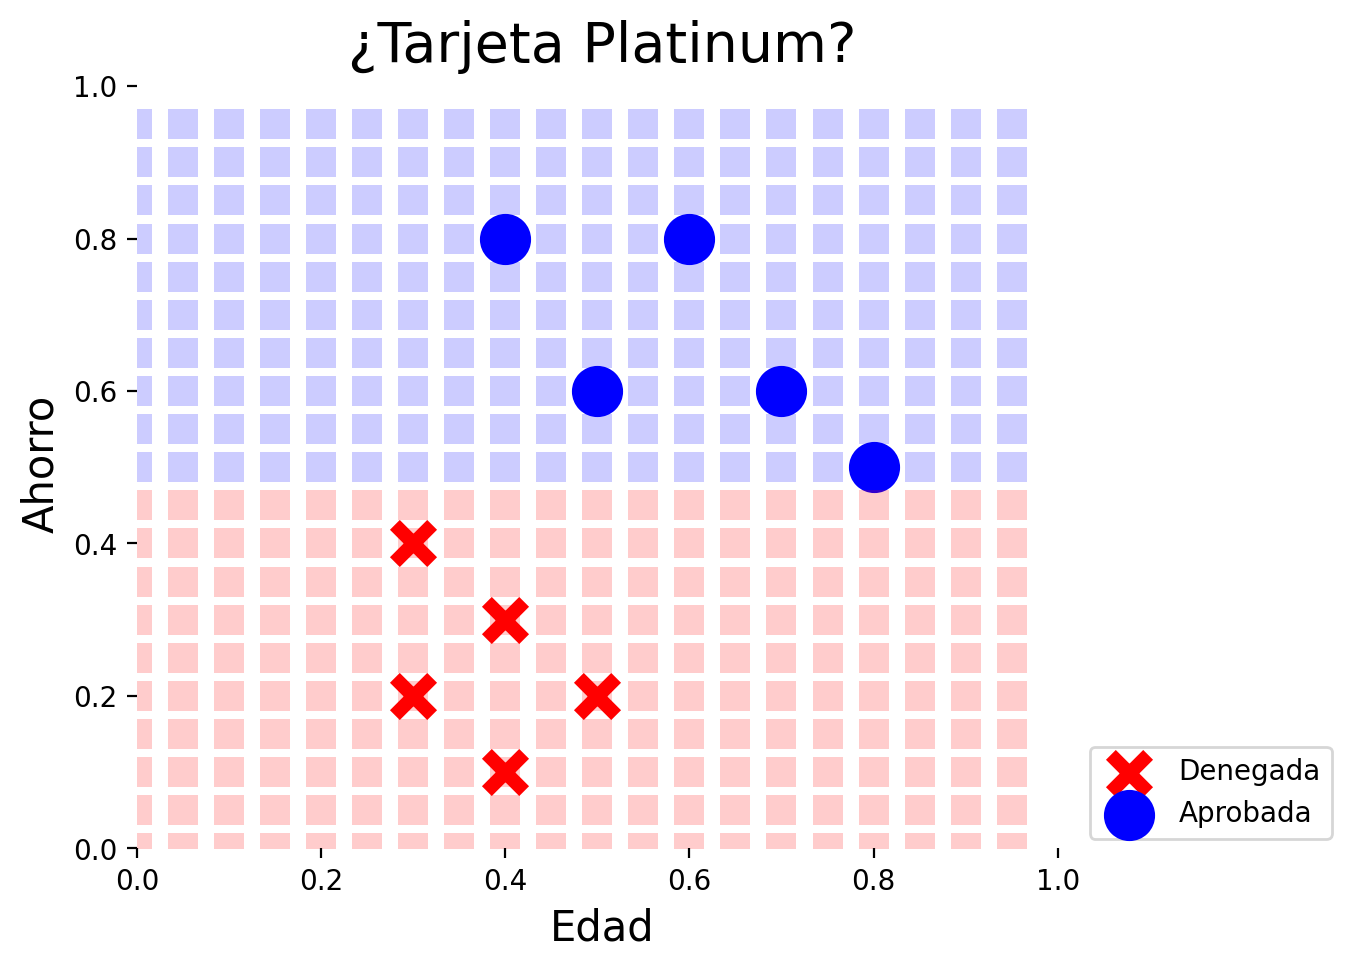

In [80]:
plt.figure(figsize=(6, 5), dpi=200)
plt.title("¿Tarjeta Platinum?", fontsize=20)

plt.scatter(personas[clases == 0].T[0],
            personas[clases == 0].T[1],
            marker="x", s=180, color="red",
            linewidths=5, label="Denegada")

plt.scatter(personas[clases == 1].T[0],
            personas[clases == 1].T[1],
            marker="o", s=180, color="blue",
            linewidths=5, label="Aprobada")

for edad in np.arange(0, 1, 0.05):
    for ahorro in np.arange(0, 1, 0.05):
        color = activacion(pesos, [edad, ahorro], b)
        if color == 1:
            plt.scatter(edad, ahorro, marker="s", s=110,
                        color="blue", alpha=0.2, linewidths=0)
        else:
            plt.scatter(edad, ahorro, marker="s", s=110,
                        color="red", alpha=0.2, linewidths=0)

plt.xlabel("Edad", fontsize=15)
plt.ylabel("Ahorro", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False)
plt.xlim((0, 1.01))
plt.ylim((0, 1.01))
plt.show()

Perceptrón usando Sklearn

In [81]:
from sklearn.linear_model import Perceptron

personas = np.array([[0.3, 0.4], [0.4, 0.3],
                     [0.3, 0.2], [0.4, 0.1],
                     [0.5, 0.2], [0.4, 0.8],
                     [0.6, 0.8], [0.5, 0.6],
                     [0.7, 0.6], [0.8, 0.5]])

# 1 : aprobrada    0 : denegada
clases = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])


perceptron = Perceptron().fit(personas, clases)
perceptron.predict([[0.3, 0.7], [0.8, 0.8]])

array([1, 1])